In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv('../data/clean_audio_data.csv')
df.head()

,clue_id,transcript,clue_word_frequency,duration,clue_latency,clue_number_latency,speech_rate,speech_ratio,articulation_rate,pause_count,...,energy_mean,energy_std,energy_range,energy_p25,energy_p75,jitter,shimmer,hnr,confidence,difficulty
0,1,"Okay, let me see here. So, mm-hmm. Alright, t...",0.758687,0.320794,0.910926,0.000000,-0.051565,-0.203309,-0.271700,1.287504,...,-0.334261,0.476862,0.511001,-0.614592,-0.043920,-0.877806,0.759071,0.673909,Neutral,Easy
1,2,homo sapiens to,-2.284780,0.000000,0.000000,0.351803,-0.634625,-1.068199,-0.024220,-0.460494,...,-0.763587,0.627788,-0.349708,-0.614592,-0.929246,1.053497,1.899701,-1.215064,Confident,Easy
2,3,Amendment Now.,0.994141,0.000000,0.000000,0.000000,2.376291,0.441978,2.181183,-0.798816,...,2.096818,-2.601546,-1.518996,-0.614592,1.697958,0.284817,0.306589,0.074622,Confident,Easy
3,4,"This is tough here. Scalpi sensor, 2.",-0.252896,0.000000,0.452498,0.820813,-0.558376,-0.965797,-0.161107,0.159763,...,-0.694616,0.472000,0.149989,-0.614592,-0.878693,1.926226,1.663184,-2.011055,Non-confident,Difficult
4,5,"See, I don't know how to link some of these. ...",-0.261616,0.488518,0.000000,0.000000,0.367425,1.421530,-0.506610,-0.404107,...,0.187358,0.150984,0.007847,1.768796,-0.245707,0.113547,-0.186251,0.036165,Confident,Neutral


In [3]:
df = df.drop(columns=["confidence"])

## 1. Select Features

Based on the random forest model observations, the following features are going to be dropped:

- MFCCs (too noisy, not interpretable)
- redundant features (highly correlated)

In [6]:
selected_features = [
    "clue_latency", 
    "pause_count", 
    "verbal_hesitation_count", 
    "duration", 
    "hnr", 
    "pitch_mean", 
    "pitch_p25", 
    "jitter", 
    "pitch_range", 
    "shimmer", 
    "clue_number_latency",
    "energy_p25"
]

In [7]:
X = df[selected_features].copy()
y = df["difficulty"] 

In [8]:
# handle missing values
X = X.astype(float)
X = X.fillna(X.mean())

In [9]:
# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # important for class balance
)

In [10]:
# Sanity Check
print(X_train.shape)
print(X_train.isna().sum().sum())
print(y_train.value_counts())

(40, 12)
0
difficulty
Easy         21
Difficult    12
Neutral       7
Name: count, dtype: int64


## 2. Train Logistic Regression & Extract Weights

In [11]:
# train
clf = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [12]:
# inspect coefficients
coef_df = pd.DataFrame(
    clf.coef_.T,
    index=X_train.columns,
    columns=clf.classes_
)
coef_df

,Difficult,Easy,Neutral
clue_latency,1.003334,-0.671879,-0.331455
pause_count,0.941878,0.061029,-1.002907
verbal_hesitation_count,0.102976,-0.358512,0.255536
duration,0.696460,-0.569619,-0.126841
hnr,-0.389181,0.043291,0.345890
pitch_mean,0.276670,0.168598,-0.445268
pitch_p25,0.207169,0.601912,-0.809081
jitter,0.695539,-0.431094,-0.264444
pitch_range,-0.533651,0.492609,0.041041
shimmer,-0.256453,0.602665,-0.346211


In [14]:
# make it interpretable
# positive weights signal easy clue, negative weights signal difficulty
confidence_weights = coef_df["Easy"] - coef_df["Difficult"]
confidence_weights.sort_values(ascending=False)

pitch_range                1.026260
energy_p25                 0.868919
shimmer                    0.859118
hnr                        0.432472
pitch_p25                  0.394743
pitch_mean                -0.108073
verbal_hesitation_count   -0.461488
pause_count               -0.880849
clue_number_latency       -0.964072
jitter                    -1.126633
duration                  -1.266079
clue_latency              -1.675212
dtype: float64

## 3. Build Confidence Score

In [15]:
weights = confidence_weights.to_dict()

In [16]:
def compute_confidence_score(row, weights):
    score = 0.0
    for feature, w in weights.items():
        score += w * row[feature]
    return score

In [17]:
# compute new score
df["difficulty_score"] = X.apply(lambda row: compute_confidence_score(row, weights), axis=1)

<Axes: xlabel='difficulty', ylabel='difficulty_score'>

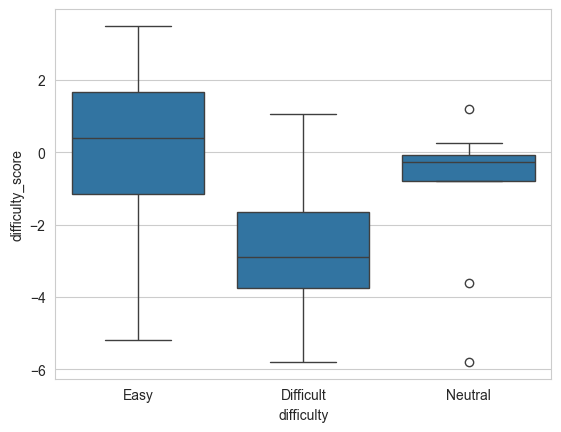

In [18]:
# inspect distribution
sns.boxplot(x=y, y=df["difficulty_score"])

## 4. Define Thresholds

In [19]:
# inspect score distribution
df.groupby("difficulty")["difficulty_score"].describe()

,count,mean,std,min,25%,50%,75%,max
difficulty,,,,,,,,
Difficult,15.0,-2.759724,1.960638,-5.789554,-3.742792,-2.891820,-1.657232,1.049668
Easy,26.0,0.204470,1.830580,-5.183662,-1.145166,0.402393,1.656620,3.491945
Neutral,9.0,-1.108120,2.185445,-5.790880,-0.795338,-0.261602,-0.084207,1.187596


In [20]:
# define thresholds:
# below low_thresh → likely easy
# above high_thresh → likely difficult
low_thresh = df[df["difficulty"] == "Easy"]["difficulty_score"].quantile(0.75)
high_thresh = df[df["difficulty"] == "Difficult"]["difficulty_score"].quantile(0.25)

In [21]:
# decision function
def classify_difficulty(score, low, high):
    if score <= low:
        return "Easy"
    elif score >= high:
        return "Difficult"
    else:
        return "Neutral"

def prediction_strength(score, low, high):
    if score < low:
        return low - score
    elif score > high:
        return score - high
    else:
        return min(score - low, high - score)

In [22]:
df["difficulty_pred_rule"] = df["difficulty_score"].apply(lambda s: classify_difficulty(s, low_thresh, high_thresh))
df["prediction_strength"] = df["difficulty_score"].apply(lambda s: prediction_strength(s, low_thresh, high_thresh))

In [23]:
max_strength = df["prediction_strength"].max()
df["strength_norm"] = df["prediction_strength"] / max_strength

## 5. Evaluation

In [24]:
print(classification_report(df["difficulty"], df["difficulty_pred_rule"]))

              precision    recall  f1-score   support

   Difficult       0.00      0.00      0.00        15
        Easy       0.44      0.73      0.55        26
     Neutral       0.00      0.00      0.00         9

    accuracy                           0.38        50
   macro avg       0.15      0.24      0.18        50
weighted avg       0.23      0.38      0.29        50



/Users/clara/Desktop/VU/Thesis/beyond-speech-hri/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/clara/Desktop/VU/Thesis/beyond-speech-hri/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/clara/Desktop/VU/Thesis/beyond-speech-hri/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

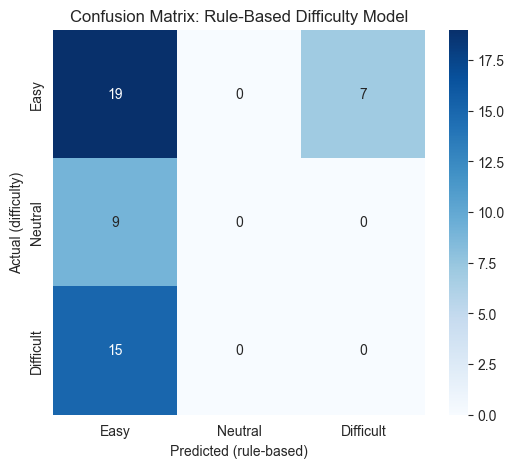

In [26]:
# Ensure same label order
labels = ["Easy", "Neutral", "Difficult"]

cm = confusion_matrix(df["difficulty"], df["difficulty_pred_rule"], labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.ylabel("Actual (difficulty)")
plt.xlabel("Predicted (rule-based)")
plt.title("Confusion Matrix: Rule-Based Difficulty Model")
plt.show()

In [27]:
# check correctness
df["correct"] = df["difficulty"] == df["difficulty_pred_rule"]
df.groupby("correct")["strength_norm"].describe()

,count,mean,std,min,25%,50%,75%,max
correct,,,,,,,,
False,31.0,0.576180,0.285663,0.062977,0.326257,0.613789,0.764211,1.000000
True,19.0,0.295799,0.203951,0.002708,0.153344,0.299444,0.383841,0.918467


<Axes: xlabel='correct', ylabel='strength_norm'>

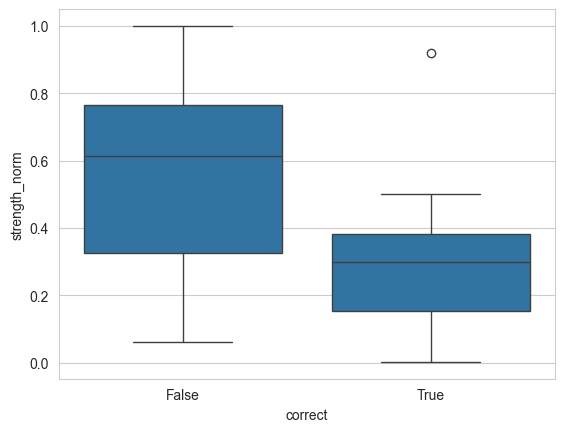

In [28]:
sns.boxplot(x="correct", y="strength_norm", data=df)

In [29]:
df[df["correct"] == False][["difficulty", "difficulty_pred_rule", "strength_norm"]].sort_values("strength_norm")

,difficulty,difficulty_pred_rule,strength_norm
43,Neutral,Easy,0.062977
12,Difficult,Easy,0.081497
31,Difficult,Easy,0.184438
4,Neutral,Easy,0.189430
8,Neutral,Easy,0.233746
14,Neutral,Easy,0.238860
48,Neutral,Easy,0.257566
49,Neutral,Easy,0.323281
9,Neutral,Easy,0.329232
23,Difficult,Easy,0.378758


## 6. Final Predictions with strength threshold

In [30]:
strength_thresh = 0.25

def final_prediction(row):
    if row["strength_norm"] < strength_thresh:
        return "Uncertain"   # reject low-confidence predictions
    else:
        return row["difficulty_pred_rule"]

df["difficulty_final"] = df.apply(final_prediction, axis=1)

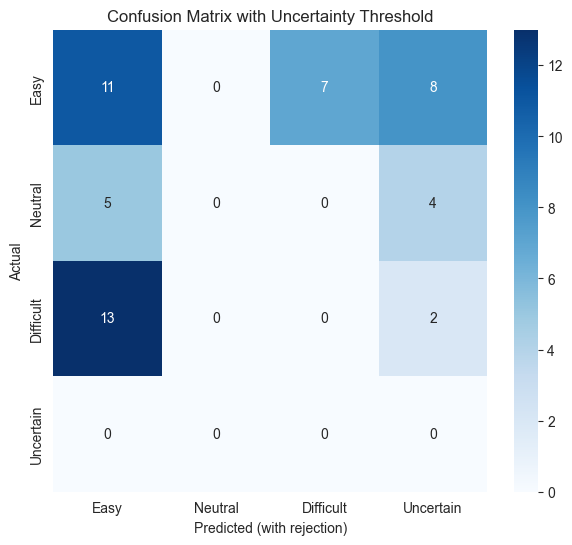

In [31]:
labels = ["Easy", "Neutral", "Difficult", "Uncertain"]

cm = confusion_matrix(df["difficulty"], df["difficulty_final"], labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(7,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.ylabel("Actual")
plt.xlabel("Predicted (with rejection)")
plt.title("Confusion Matrix with Uncertainty Threshold")
plt.show()

In [37]:
# Choosing the best threshold value (0.2, 0.25, 0.3, 0.4): tradeoff between accuracy & coverage
# Important: reliable robot behavior
threshold = 0.05

kept = df[df["strength_norm"] >= threshold]
accuracy = (kept["correct"]).mean()
coverage = len(kept) / len(df)

print("Accuracy:", accuracy)
print("Coverage:", coverage)

Accuracy: 0.3673469387755102
Coverage: 0.98
